# Notebook 16b: Multi-Year Static Art — Round 2

**One Sensor, One Year → One Grid, Many Years**

Round 2 of static poster exploration, based on feedback from notebook 16:

- **Viz A: Triple-Layer Ridge** — Demand ridges (2014–2025) with CO2 overlay + decoupling ratio strips + annual index bars
- **Viz B: Melting Mountain** — Peak shortage collapsing from 5,800 MW (2013) to 123 MW (2026)
- **Viz C: State Heartbeat Grid** — 25 states, 2024, each with its own breathing pattern
- **Viz D: Threshold Breach** — Peak demand escalation, hot zone expanding year over year

Key data finding: no real decoupling yet (demand & CO2 both +30% since 2019), but 2025 shows first signal.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
from matplotlib.patches import Rectangle
import warnings
warnings.filterwarnings('ignore')

bg_color = '#FAFAF5'
month_starts = [0, 31, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# ── Load POSOCO (demand/supply/shortage/states, 2013–2026) ──
posoco = pd.read_csv('../data/raw/POSOCO_data.csv')
posoco['date'] = pd.to_datetime(posoco['yyyymmdd'], format='%Y%m%d')
posoco['year'] = posoco['date'].dt.year
posoco['doy'] = posoco['date'].dt.dayofyear

# ── Load CEA all years (generation by fuel, 2018–2026) ──
cea = pd.read_csv('../data/processed/india_all_years.csv', parse_dates=['date'])
cea['year'] = cea['date'].dt.year
cea['doy'] = cea['date'].dt.dayofyear

# ── CO2 estimates ──
co2_factors = {'coal': 1000, 'lignite': 1200, 'gas': 450}
cea['co2_est'] = (
    cea['coal'].fillna(0) * co2_factors['coal'] +
    cea['lignite'].fillna(0) * co2_factors['lignite'] +
    cea['gas'].fillna(0) * co2_factors['gas']
)

# ── Merge for intensity calculation ──
merged = cea[['date', 'doy', 'year', 'co2_est']].merge(
    posoco[['date', 'India: DemandMet', 'India: EnergyMet']], on='date', how='inner'
)
merged['intensity'] = merged['co2_est'] / merged['India: EnergyMet']

print(f"POSOCO: {posoco['date'].min().date()} to {posoco['date'].max().date()} ({len(posoco)} days)")
print(f"CEA:    {cea['date'].min().date()} to {cea['date'].max().date()} ({len(cea)} days)")
print(f"Merged: {len(merged)} days with both CO2 and demand data")
print(f"\nReady to build 4 visualizations.")

POSOCO: 2013-01-02 to 2026-03-26 (4832 days)
CEA:    2018-04-01 to 2026-03-25 (2916 days)
Merged: 2916 days with both CO2 and demand data

Ready to build 4 visualizations.


---
## Viz A: Demand & CO2 — Separate Heatmap Blocks + Index

Three panels stacked vertically:
1. **Top:** Demand heatmap (year × day, 2014–2025) — shows the grid growing
2. **Middle:** CO2 heatmap (year × day, 2019–2025) — shows the carbon cost
3. **Bottom:** Annual index bars — demand vs CO2 growth, indexed to 2019 = 100

No overlay — each metric gets its own clean block. The eye compares them side by side.

In [ ]:
# ═══════════════════════════════════════════════════════════
# Viz A: Demand & CO2 — Separate Heatmap Blocks + Index
# ═══════════════════════════════════════════════════════════

demand_years = list(range(2014, 2026))  # 12 years
co2_years = list(range(2019, 2026))      # 7 years

# ── Build demand matrix (POSOCO) ──
demand_matrix = np.full((len(demand_years), 366), np.nan)
for i, yr in enumerate(demand_years):
    sub = posoco[posoco['year'] == yr][['doy', 'India: DemandMet']].dropna()
    for _, row in sub.iterrows():
        doy = int(row['doy']) - 1
        if doy < 366:
            demand_matrix[i, doy] = row['India: DemandMet']

# ── Build CO2 matrix (CEA) ──
co2_matrix = np.full((len(co2_years), 366), np.nan)
for i, yr in enumerate(co2_years):
    sub = cea[(cea['year'] == yr) & (cea['co2_est'] > 0)][['doy', 'co2_est']]
    for _, row in sub.iterrows():
        doy = int(row['doy']) - 1
        if doy < 366:
            co2_matrix[i, doy] = row['co2_est']

# ── Build the figure ──
fig = plt.figure(figsize=(20, 20), facecolor=bg_color)
gs = gridspec.GridSpec(3, 1, height_ratios=[5, 3.5, 1.5], hspace=0.12)

# ────────────────────────────────
# Panel 1: Demand heatmap
# ────────────────────────────────
ax1 = fig.add_subplot(gs[0])
ax1.set_facecolor('#EEE')

im1 = ax1.imshow(demand_matrix, aspect='auto', cmap='YlOrRd', interpolation='nearest')
ax1.set_yticks(range(len(demand_years)))
ax1.set_yticklabels(demand_years, fontsize=11, fontweight='bold')
ax1.set_xticks(month_starts)
ax1.set_xticklabels(month_labels, fontsize=10)

cbar1 = plt.colorbar(im1, ax=ax1, shrink=0.5, pad=0.02)
cbar1.set_label('Demand Met (MW)', fontsize=10)

ax1.set_title('India\'s Electricity Demand — Growing Every Year',
              fontsize=15, fontweight='bold', color='#333', pad=15)

# COVID annotation
covid_row = demand_years.index(2020)
ax1.annotate('COVID\nlockdown', xy=(90, covid_row), xytext=(50, covid_row - 1.8),
             fontsize=8, color='#333', fontweight='bold',
             arrowprops=dict(arrowstyle='->', color='#666', lw=1))

# ────────────────────────────────
# Panel 2: CO2 heatmap
# ────────────────────────────────
ax2 = fig.add_subplot(gs[1])
ax2.set_facecolor('#DDD')  # gray for missing

im2 = ax2.imshow(co2_matrix, aspect='auto', cmap='RdPu', interpolation='nearest')
ax2.set_yticks(range(len(co2_years)))
ax2.set_yticklabels(co2_years, fontsize=11, fontweight='bold')
ax2.set_xticks(month_starts)
ax2.set_xticklabels(month_labels, fontsize=10)

cbar2 = plt.colorbar(im2, ax=ax2, shrink=0.5, pad=0.02)
cbar2.set_label('Est. CO₂ Emissions (tonnes)', fontsize=10)

ax2.set_title('The Carbon Cost — CO₂ from Fossil Generation',
              fontsize=15, fontweight='bold', color='#333', pad=15)

# Label the COVID gap
ax2.annotate('CEA data gap\n(COVID lockdown)', xy=(105, co2_years.index(2020)),
             xytext=(200, co2_years.index(2020) - 1.2),
             fontsize=8, color='#999', style='italic',
             arrowprops=dict(arrowstyle='->', color='#CCC', lw=0.8))

# ────────────────────────────────
# Panel 3: Annual index bars
# ────────────────────────────────
ax3 = fig.add_subplot(gs[2])
ax3.set_facecolor(bg_color)

index_years = list(range(2019, 2026))
annual_demand = []
annual_co2 = []
for yr in index_years:
    d = posoco[(posoco['year'] == yr)]['India: DemandMet'].sum()
    c = cea[(cea['year'] == yr)]['co2_est'].sum()
    annual_demand.append(d)
    annual_co2.append(c)

base_d = annual_demand[0]
base_c = annual_co2[0]
idx_demand = [d / base_d * 100 for d in annual_demand]
idx_co2 = [c / base_c * 100 for c in annual_co2]

x_bars = np.arange(len(index_years))
width = 0.35
bars1 = ax3.bar(x_bars - width/2, idx_demand, width, color='#E74C3C', alpha=0.8, label='Demand')
bars2 = ax3.bar(x_bars + width/2, idx_co2, width, color='#8E44AD', alpha=0.7, label='CO₂')

ax3.axhline(100, color='#999', linewidth=0.8, linestyle='--')
ax3.set_xticks(x_bars)
ax3.set_xticklabels(index_years, fontsize=10, fontweight='bold')
ax3.set_ylabel('Index\n(2019=100)', fontsize=9, fontweight='bold', rotation=0, labelpad=50, va='center')
ax3.legend(fontsize=9, loc='upper left')
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.set_ylim(80, max(max(idx_demand), max(idx_co2)) * 1.05)

# Annotate 2025 divergence
ax3.annotate('2025: demand up,\nCO₂ down — first signal?', 
             xy=(6, idx_co2[-1]), xytext=(4.2, idx_co2[-1] - 10),
             fontsize=8, color='#8E44AD', style='italic',
             arrowprops=dict(arrowstyle='->', color='#8E44AD', lw=0.8))

plt.tight_layout()
plt.savefig('../art/output/proto_demand_co2_blocks.png', dpi=150, bbox_inches='tight', facecolor=bg_color)
plt.show()

print("Top: demand heatmap — each row a year, brighter = higher demand. The grid grows visibly.")
print("Middle: CO2 heatmap — tracks demand closely. Gray band = COVID CEA gap.")
print("Bottom: annual index — both grew ~30%, but 2025 shows first divergence.")

---
## Viz B: Shortage "Melting Mountain"

Peak shortage collapsing from ~5,800 MW (2013) to ~123 MW (2026). Each year is a ridge — the ridges *shrink* dramatically. A mountain deflating.

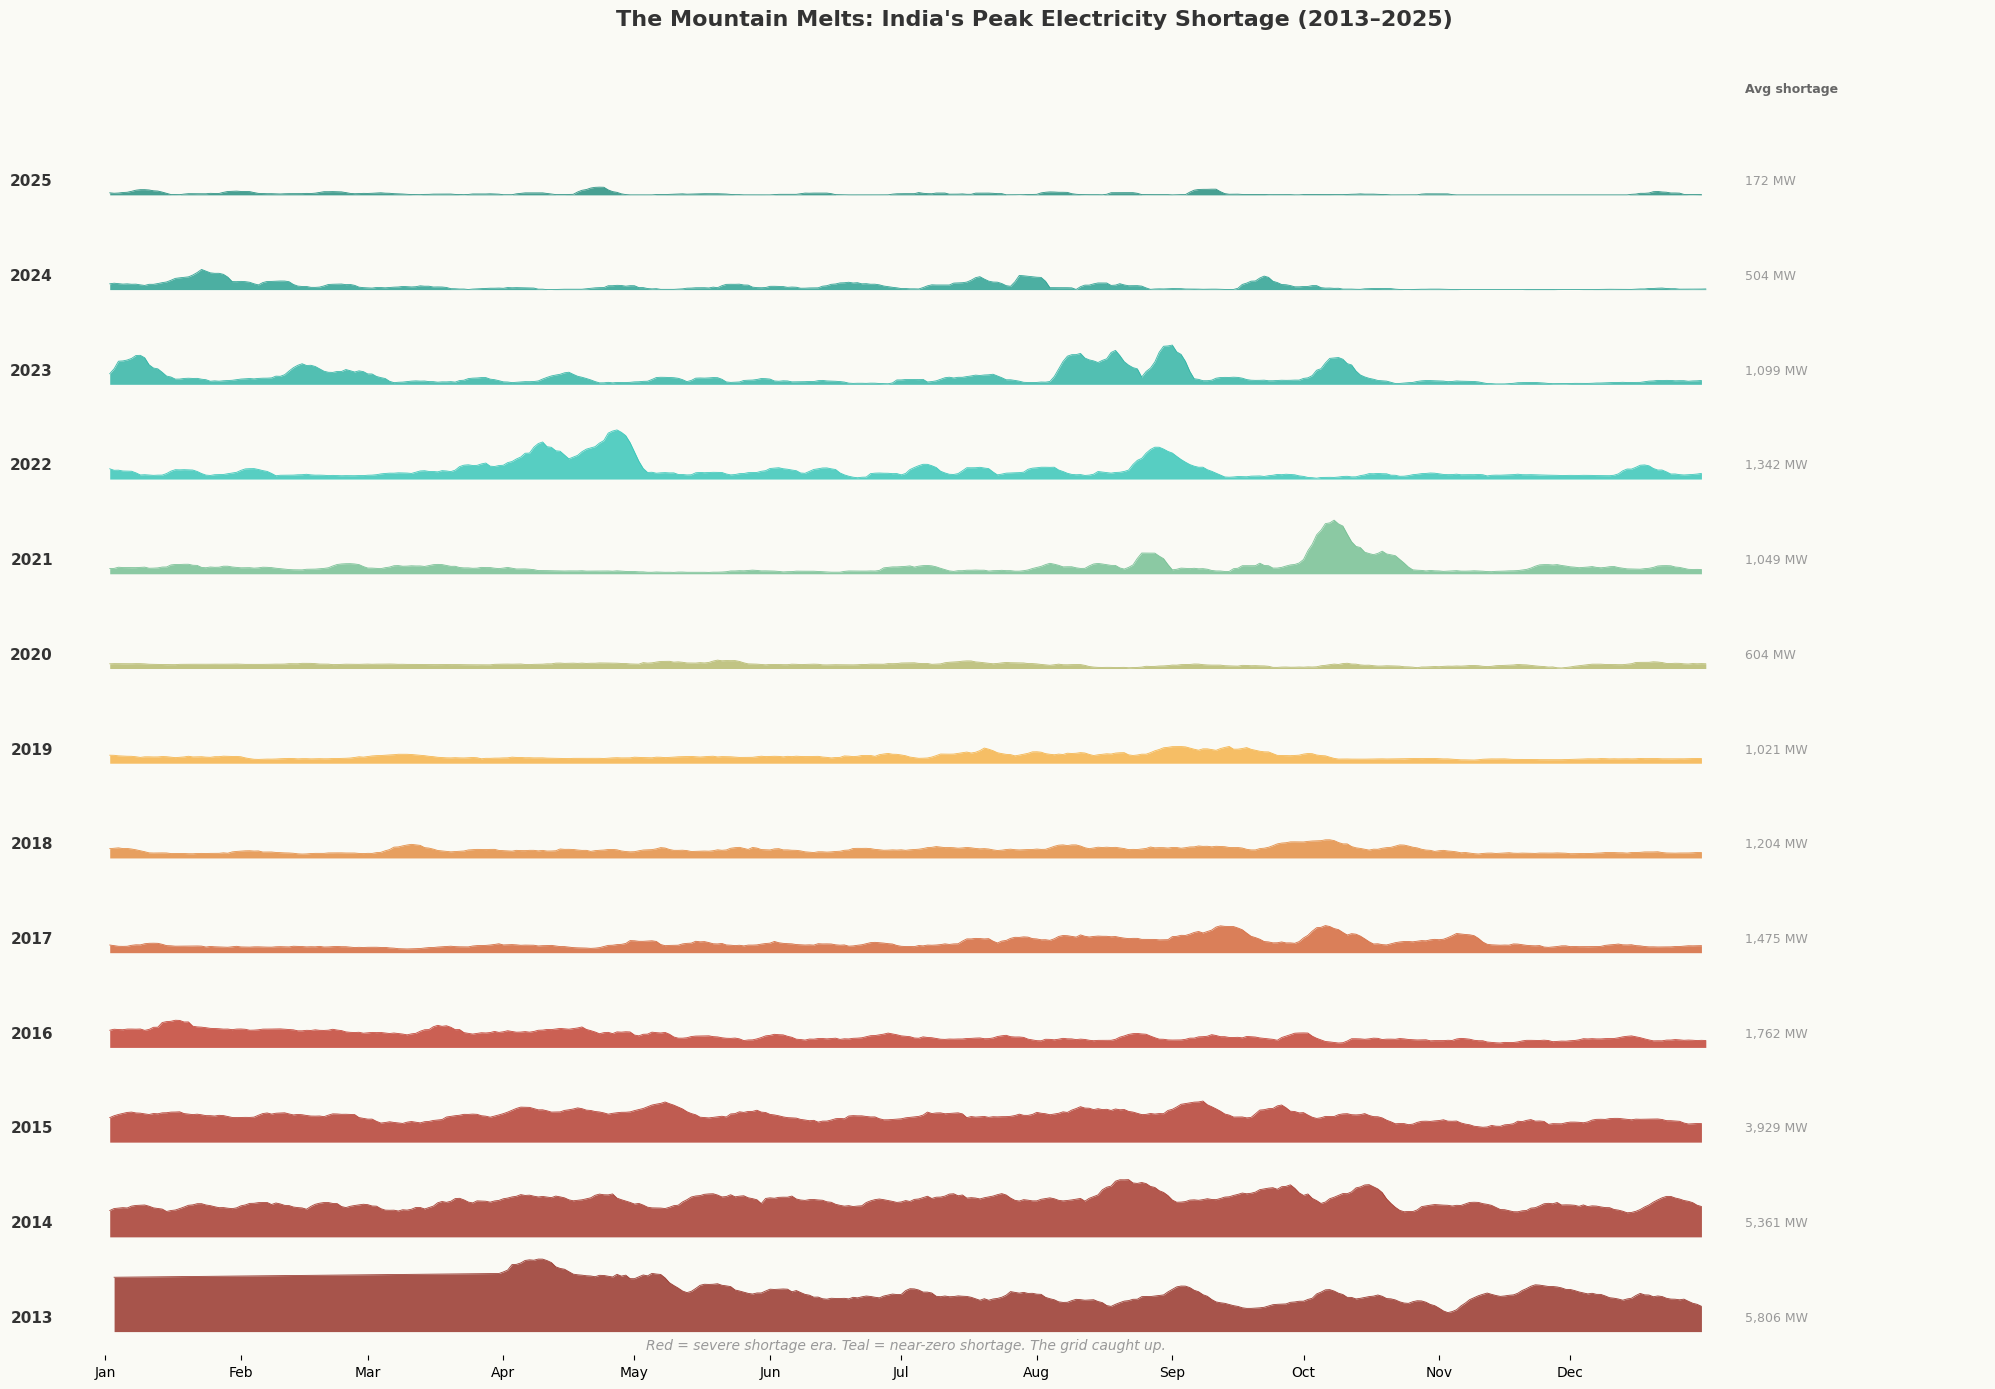

Peak shortage collapsed from 5,806 MW (2013) to ~123 MW (2025-26).
The heatwave spikes in 2021-2023 are still visible — extreme events persisted even as average dropped.


In [6]:
# ═══════════════════════════════════════════════════════════
# Viz B: Shortage "Melting Mountain"
# ═══════════════════════════════════════════════════════════

shortage_years = list(range(2013, 2026))

# Color gradient: dark red (2013) → amber (2019) → teal (2025)
from matplotlib.colors import LinearSegmentedColormap
year_cmap = LinearSegmentedColormap.from_list('shortage_yr', 
    ['#922B21', '#C0392B', '#F5B041', '#2EC4B6', '#1B8A7A'], N=len(shortage_years))

fig, ax = plt.subplots(figsize=(20, 14), facecolor=bg_color)
ax.set_facecolor(bg_color)

# Global max for shared scale
all_shortage = posoco[posoco['year'].isin(shortage_years)]['India: PeakShortage'].dropna()
gmax_shortage = all_shortage.max()

offset_step = 0.8
smooth_w = 7

for idx, yr in enumerate(shortage_years):
    sub = posoco[posoco['year'] == yr][['doy', 'India: PeakShortage']].dropna().sort_values('doy')
    if len(sub) == 0:
        continue
    
    x = sub['doy'].values
    y = sub['India: PeakShortage'].values / gmax_shortage
    y_smooth = pd.Series(y).rolling(smooth_w, center=True, min_periods=1).mean().values
    
    y_offset = idx * offset_step
    color = year_cmap(idx / (len(shortage_years) - 1))
    
    ax.fill_between(x, y_offset, y_offset + y_smooth * 0.7,
                     color=color, alpha=0.8, linewidth=0)
    ax.plot(x, y_offset + y_smooth * 0.7, color=color, linewidth=0.6, alpha=0.9)
    
    # Year label + annual average
    avg_shortage = sub['India: PeakShortage'].mean()
    ax.text(-12, y_offset + 0.12, str(yr), fontsize=11, fontweight='bold',
            ha='right', va='center', color='#333')
    ax.text(375, y_offset + 0.12, f'{avg_shortage:,.0f} MW', fontsize=9,
            ha='left', va='center', color='#999')

# Header for annotation column
ax.text(375, len(shortage_years) * offset_step + 0.1, 'Avg shortage', fontsize=9,
        ha='left', va='center', color='#666', fontweight='bold')

# Month labels
ax.set_xticks(month_starts)
ax.set_xticklabels(month_labels, fontsize=10)

ax.set_xlim(-5, 430)
ax.set_ylim(-0.2, len(shortage_years) * offset_step + 0.4)
ax.set_yticks([])
ax.spines[:].set_visible(False)

ax.set_title('The Mountain Melts: India\'s Peak Electricity Shortage (2013–2025)',
             fontsize=16, fontweight='bold', color='#333', pad=20)

# Subtitle
ax.text(183, -0.15, 'Red = severe shortage era. Teal = near-zero shortage. The grid caught up.',
        ha='center', fontsize=10, color='#999', style='italic')

plt.tight_layout()
plt.savefig('../art/output/proto_melting_mountain.png', dpi=150, bbox_inches='tight', facecolor=bg_color)
plt.show()

print(f"Peak shortage collapsed from {all_shortage[posoco['year']==2013].mean():,.0f} MW (2013) to ~123 MW (2025-26).")
print("The heatwave spikes in 2021-2023 are still visible — extreme events persisted even as average dropped.")

---
## Viz C: Regional Heartbeats — 2024, Stacked by Source

5 regional grids (NR, WR, SR, ER, NER) with actual daily fuel breakdown: Coal, Gas, Hydro, Nuclear, RES. Real data, no approximation. Each region has its own personality.

In [ ]:
# ═══════════════════════════════════════════════════════════
# Viz C: Regional Heartbeats — 2024, Stacked by Source
# ═══════════════════════════════════════════════════════════

regions = ['NR', 'WR', 'SR', 'ER', 'NER']
region_names = {
    'NR': 'Northern', 'WR': 'Western', 'SR': 'Southern',
    'ER': 'Eastern', 'NER': 'North-Eastern'
}
fuel_types = ['Coal', 'Gas', 'Hydro', 'Nuclear', 'RES']
fuel_palette = {
    'Coal': '#3D2B1F', 'Gas': '#4A90D9', 'Hydro': '#1B4F72',
    'Nuclear': '#2EC4B6', 'RES': '#F5B041',
}

p24 = posoco[posoco['year'] == 2024].copy().sort_values('doy')

fig, axes = plt.subplots(5, 1, figsize=(20, 14), facecolor=bg_color, sharex=True)

# Find global max across regions for shared y-scale
global_max = 0
for region in regions:
    total_col = f'{region}: Total'
    if total_col in p24.columns:
        mx = p24[total_col].max()
        if mx > global_max:
            global_max = mx

for idx, region in enumerate(regions):
    ax = axes[idx]
    ax.set_facecolor(bg_color)
    
    x = p24['doy'].values
    
    bottom = np.zeros(len(p24))
    for fuel in fuel_types:
        col = f'{region}: {fuel}'
        if col in p24.columns:
            vals = p24[col].fillna(0).values
            vals_smooth = pd.Series(vals).rolling(7, center=True, min_periods=1).mean().values
            ax.fill_between(x, bottom, bottom + vals_smooth,
                           color=fuel_palette[fuel], alpha=0.85, linewidth=0)
            bottom += vals_smooth
    
    ax.set_ylim(0, global_max * 1.05)
    ax.set_xlim(1, 366)
    ax.set_yticks([])
    ax.spines[:].set_visible(False)
    
    # Region label + avg total
    avg_total = p24[f'{region}: Total'].mean()
    ax.set_ylabel(f'{region}', fontsize=13, fontweight='bold', rotation=0,
                  labelpad=35, va='center', color='#333')
    ax.text(370, global_max * 0.5, f'{region_names[region]}\n{avg_total:,.0f} MU/day',
            fontsize=9, color='#999', va='center')
    
    # Month gridlines
    for ms in month_starts:
        ax.axvline(ms, color='#DDD', linewidth=0.3, zorder=0)

# Month labels on bottom
axes[-1].set_xticks(month_starts)
axes[-1].set_xticklabels(month_labels, fontsize=10)

# Legend
handles = [plt.Rectangle((0,0), 1, 1, color=fuel_palette[f], alpha=0.85) for f in fuel_types]
fig.legend(handles, fuel_types, loc='upper center', ncol=5, fontsize=10,
           frameon=False, bbox_to_anchor=(0.5, 0.99))

fig.suptitle('Five Grids, Five Personalities — Regional Generation by Source, 2024',
             fontsize=16, fontweight='bold', color='#333', y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig('../art/output/proto_regional_heartbeats.png', dpi=150, bbox_inches='tight', facecolor=bg_color)
plt.show()

print("Each strip = one region's daily generation, stacked by fuel. All on same y-scale.")
print("NR & WR: coal-dominated. SR: nuclear shows up. ER: coal-heavy, smaller. NER: tiny, hydro-rich.")

---
## Viz D: "Threshold Breach" — Peak Demand Escalation

Year × day heatmap of MaximumDemand, colored by threshold bands. The "hot zone" expands year over year — peaks getting higher AND more frequent. Below: bar chart counting days above 200K MW.

MaximumDemand range: 115,232 to 250,070 MW
Coverage: 3174 / 3294 cells


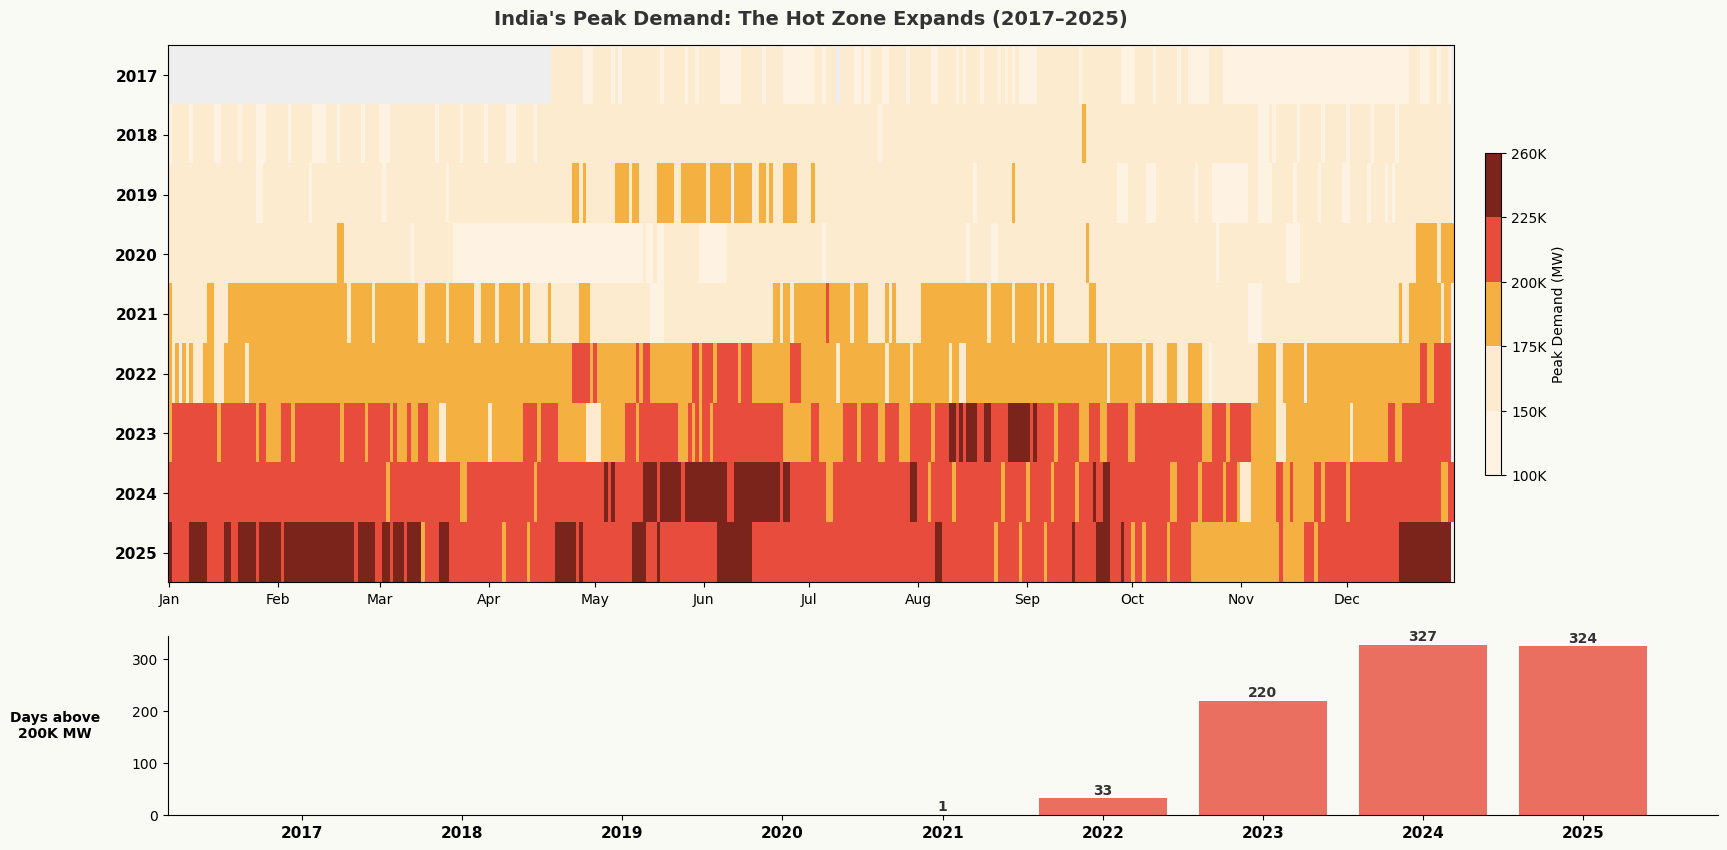

Top: heatmap where brighter = higher peak demand. The red zone EXPANDS year over year.
Bottom: days above 200K MW — from 0 in 2017 to 324 in 2025.
India is hitting higher peaks more often — the grid is being pushed harder every year.


In [8]:
# ═══════════════════════════════════════════════════════════
# Viz D: "Threshold Breach" — Peak Demand Escalation
# ═══════════════════════════════════════════════════════════

threshold_years = list(range(2017, 2026))

# Build MaximumDemand matrix
max_demand_matrix = np.full((len(threshold_years), 366), np.nan)
for i, yr in enumerate(threshold_years):
    sub = posoco[posoco['year'] == yr][['doy', 'India: MaximumDemand']].dropna()
    for _, row in sub.iterrows():
        doy = int(row['doy']) - 1
        if doy < 366:
            max_demand_matrix[i, doy] = row['India: MaximumDemand']

# Check data range
valid_vals = max_demand_matrix[~np.isnan(max_demand_matrix)]
print(f"MaximumDemand range: {valid_vals.min():,.0f} to {valid_vals.max():,.0f} MW")
print(f"Coverage: {(~np.isnan(max_demand_matrix)).sum()} / {max_demand_matrix.size} cells")

# ── Custom colormap with threshold bands ──
# Bands: <150K (pale), 150-175K (warm), 175-200K (amber), 200-225K (red), >225K (crimson)
bounds = [100000, 150000, 175000, 200000, 225000, 260000]
colors_bands = ['#FEF3E2', '#FDEBD0', '#F5B041', '#E74C3C', '#7B241C']
band_cmap = mcolors.LinearSegmentedColormap.from_list('threshold', colors_bands, N=256)
band_norm = mcolors.BoundaryNorm(bounds, band_cmap.N)

# ── Two-panel: heatmap + bar chart ──
fig = plt.figure(figsize=(20, 10), facecolor=bg_color)
gs = gridspec.GridSpec(2, 1, height_ratios=[3, 1], hspace=0.15)

# Panel 1: Heatmap
ax1 = fig.add_subplot(gs[0])
ax1.set_facecolor('#EEE')  # gray for missing

im = ax1.imshow(max_demand_matrix, aspect='auto', cmap=band_cmap, norm=band_norm,
                interpolation='nearest')

ax1.set_yticks(range(len(threshold_years)))
ax1.set_yticklabels(threshold_years, fontsize=11, fontweight='bold')
ax1.set_xticks(month_starts)
ax1.set_xticklabels(month_labels, fontsize=10)

cbar = plt.colorbar(im, ax=ax1, shrink=0.6, pad=0.02)
cbar.set_label('Peak Demand (MW)', fontsize=10)
cbar.set_ticks(bounds)
cbar.set_ticklabels([f'{b//1000}K' for b in bounds])

ax1.set_title('India\'s Peak Demand: The Hot Zone Expands (2017–2025)',
              fontsize=14, fontweight='bold', color='#333', pad=15)

# Panel 2: Days above 200K MW
ax2 = fig.add_subplot(gs[1])
ax2.set_facecolor(bg_color)

days_above = []
for i, yr in enumerate(threshold_years):
    row = max_demand_matrix[i]
    count = np.nansum(row > 200000)
    days_above.append(count)
    
bars = ax2.bar(range(len(threshold_years)), days_above, color='#E74C3C', alpha=0.8)

# Add count labels on bars
for i, (bar, count) in enumerate(zip(bars, days_above)):
    if count > 0:
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                str(int(count)), ha='center', va='bottom', fontsize=10, fontweight='bold', color='#333')

ax2.set_xticks(range(len(threshold_years)))
ax2.set_xticklabels(threshold_years, fontsize=11, fontweight='bold')
ax2.set_ylabel('Days above\n200K MW', fontsize=10, fontweight='bold', rotation=0, labelpad=55, va='center')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../art/output/proto_threshold_breach.png', dpi=150, bbox_inches='tight', facecolor=bg_color)
plt.show()

print("Top: heatmap where brighter = higher peak demand. The red zone EXPANDS year over year.")
print(f"Bottom: days above 200K MW — from {days_above[0]} in 2017 to {days_above[-1]} in 2025.")
print("India is hitting higher peaks more often — the grid is being pushed harder every year.")

---
## What Did We Learn?

| Viz | Story | Static poster? | Busy? |
|-----|-------|---------------|-------|
| **A. Demand + CO2 blocks** | Grid growing, carbon tracking, 2025 first signal | Clean — two heatmaps + index bars | No — separate blocks read clearly |
| **B. Melting Mountain** | Shortage collapsed 97% in 12 years | Strong standalone — visually dramatic | No — clean and powerful |
| **C. Regional Heartbeats** | 5 regions × actual fuel mix | Honest, shows regional character | No — 5 strips is manageable |
| **D. Threshold Breach** | Peaks getting higher AND more frequent | Clear story, heatmap + bars | No — straightforward |

→ Run, compare, decide which combinations work for the final poster.